# Step 3 — Hyperparameter Tuning

Using the Random Forest model selected in notebook 02, we perform `RandomizedSearchCV` with 5-fold cross-validation to find the best hyperparameters, then evaluate the tuned model and save it for deployment.

In [14]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the cleaned dataset from Step 2
df = pd.read_csv('../data/listings_cleaned.csv')
print("Data loaded. Shape:", df.shape)

Data loaded. Shape: (4480, 80)


In [15]:
# Create features exactly as before
df['host_verified'] = df['host_identity_verified'].map({'t': 1, 'f': 0}).fillna(0)
df['num_amenities'] = df['amenities'].str.count(',') + 1
df['price_per_person'] = df['price_clean'] / df['accommodates']
df['availability_ratio'] = df['availability_365'] / 365.0
df['is_superhost'] = df['host_is_superhost'].map({'t': 1, 'f': 0}).fillna(0)

# Encode room type
room_map = {'Entire home/apt': 2, 'Private room': 1, 'Shared room': 0, 'Hotel room': 3}
df['room_type_encoded'] = df['room_type'].map(room_map)

# Frequency encode neighbourhood
neigh_freq = df['neighbourhood_cleansed'].value_counts(normalize=True).to_dict()
df['neighbourhood_freq'] = df['neighbourhood_cleansed'].map(neigh_freq)

# Select features and target
feature_cols = [
    'bedrooms', 'bathrooms', 'accommodates', 'room_type_encoded',
    'neighbourhood_freq', 'num_amenities', 'availability_ratio',
    'is_superhost', 'host_verified'
]
X = df[feature_cols]
y = df['price_clean']

print("Features shape:", X.shape)

Features shape: (4480, 9)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 3584 samples
Test set: 896 samples


In [17]:
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1   # Shows progress
)

# This is the critical step – fit the search
print("Starting hyperparameter search...")
random_search.fit(X_train, y_train)
print("Search completed.")

Starting hyperparameter search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


Search completed.


In [18]:
print("Best parameters found:")
print(random_search.best_params_)
print(f"Best cross-validation R²: {random_search.best_score_:.4f}")

Best parameters found:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
Best cross-validation R²: 0.2050


In [19]:
best_tuned = random_search.best_estimator_
y_pred_tuned = best_tuned.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("=== Tuned Random Forest Performance ===")
print(f"MAE:  ${mae_tuned:.2f}")
print(f"RMSE: ${rmse_tuned:.2f}")
print(f"R²:   {r2_tuned:.4f}")

=== Tuned Random Forest Performance ===
MAE:  $122.00
RMSE: $149.45
R²:   0.2196


In [20]:
# Train a default Random Forest for comparison
rf_default = RandomForestRegressor(random_state=42)
rf_default.fit(X_train, y_train)
y_pred_default = rf_default.predict(X_test)

mae_default = mean_absolute_error(y_test, y_pred_default)
rmse_default = np.sqrt(mean_squared_error(y_test, y_pred_default))
r2_default = r2_score(y_test, y_pred_default)

print("=== Default Random Forest (no tuning) ===")
print(f"MAE:  ${mae_default:.2f}")
print(f"RMSE: ${rmse_default:.2f}")
print(f"R²:   {r2_default:.4f}")

print("\n=== Improvement from tuning ===")
print(f"MAE improvement: ${mae_default - mae_tuned:.2f}")
print(f"R² improvement:  {r2_tuned - r2_default:.4f}")

=== Default Random Forest (no tuning) ===
MAE:  $122.43
RMSE: $152.71
R²:   0.1852

=== Improvement from tuning ===
MAE improvement: $0.43
R² improvement:  0.0343


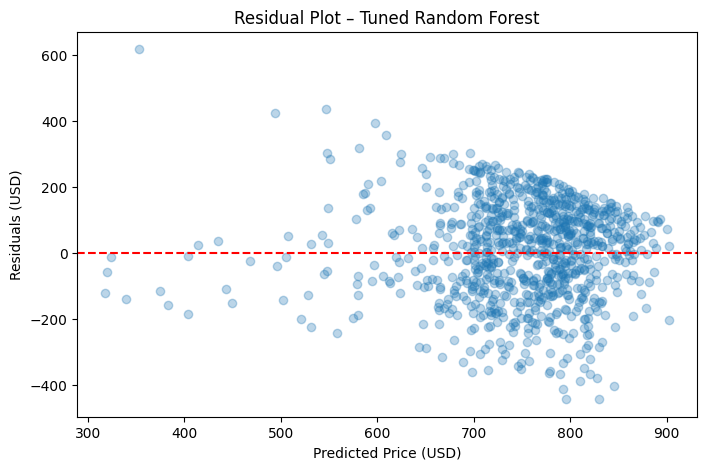

In [21]:
residuals = y_test - y_pred_tuned
plt.figure(figsize=(8,5))
plt.scatter(y_pred_tuned, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price (USD)')
plt.ylabel('Residuals (USD)')
plt.title('Residual Plot – Tuned Random Forest')
plt.show()

In [22]:
# Save the tuned model (overwrite previous model.pkl if desired)
joblib.dump(best_tuned, '../app/model_tuned.pkl')
print("Tuned model saved to ../app/model_tuned.pkl")

# Also save feature columns and neighbourhood freq if not already saved
joblib.dump(feature_cols, '../app/feature_columns.pkl')
joblib.dump(neigh_freq, '../app/neighbourhood_freq.pkl')
print("Feature columns and neighbourhood frequency saved.")

Tuned model saved to ../app/model_tuned.pkl
Feature columns and neighbourhood frequency saved.
